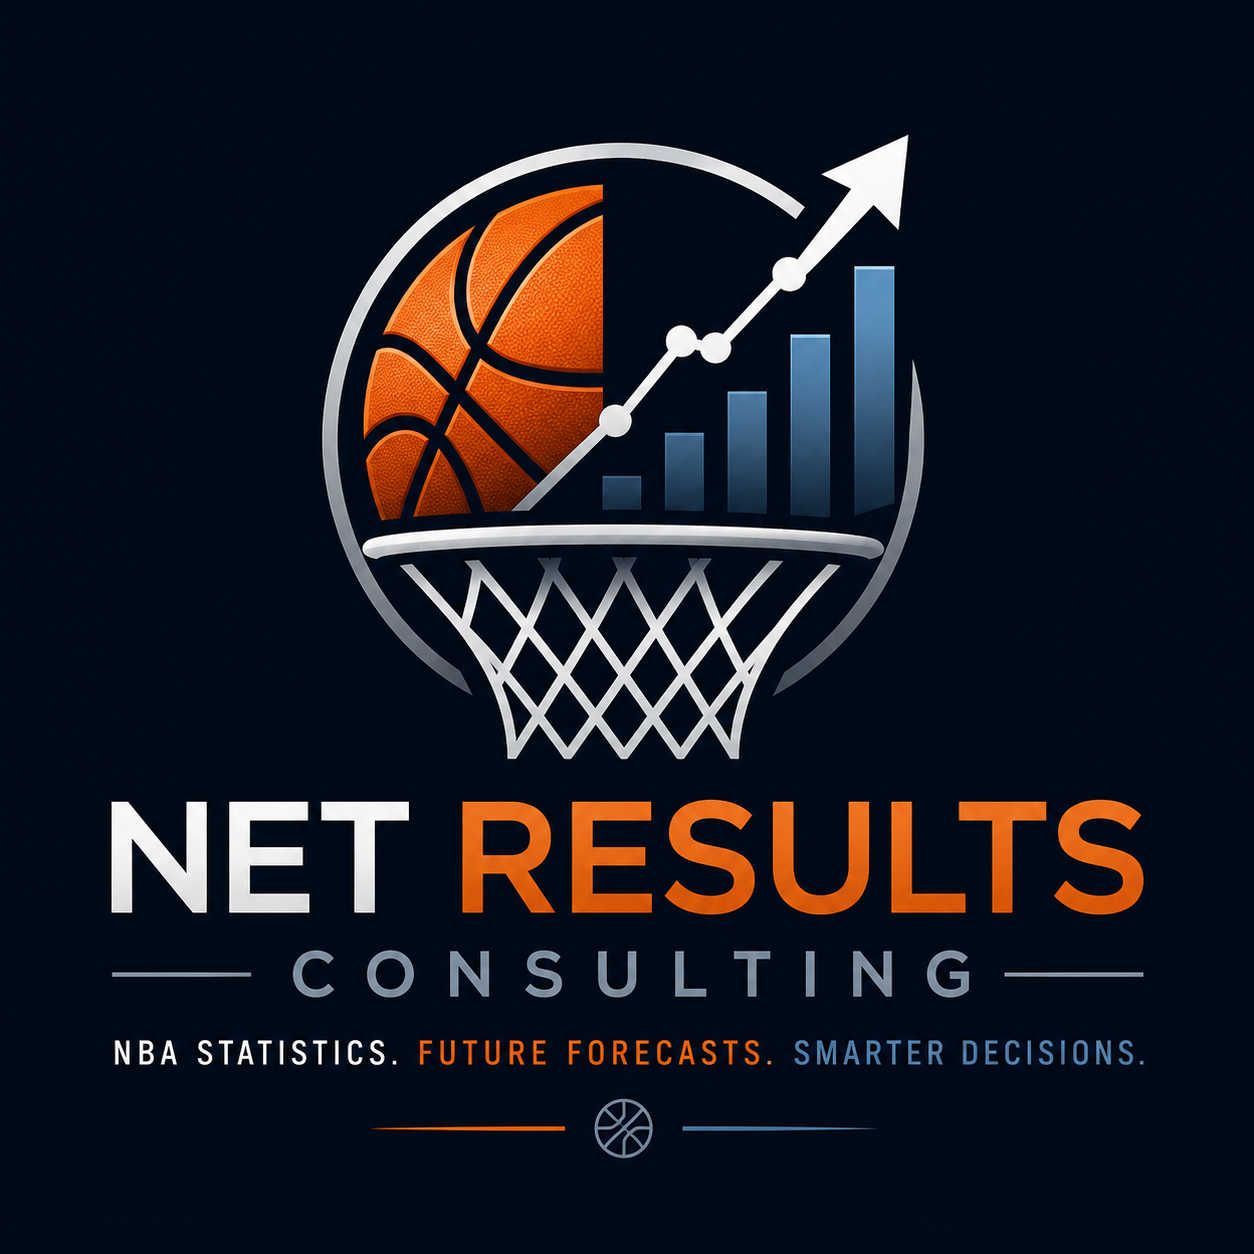

In [ ]:
#import all libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import seaborn as sn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



#***Get familar with the data***


In [ ]:
#show the data frame
df = pd.read_csv('games.csv')
df.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


#***Find and drop null values and duplicate records***

In [ ]:
#find null values
print('count')
df.isna().sum()

count


,0
GAME_DATE_EST,0
GAME_ID,0
GAME_STATUS_TEXT,0
HOME_TEAM_ID,0
VISITOR_TEAM_ID,0
SEASON,0
TEAM_ID_home,0
PTS_home,99
FG_PCT_home,99
FT_PCT_home,99


In [ ]:
df = df.dropna()

In [ ]:
df.isna().sum()

,0
GAME_DATE_EST,0
GAME_ID,0
GAME_STATUS_TEXT,0
HOME_TEAM_ID,0
VISITOR_TEAM_ID,0
SEASON,0
TEAM_ID_home,0
PTS_home,0
FG_PCT_home,0
FT_PCT_home,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

#***Drop Irrelevant and redundant columns***

In [ ]:
columns_to_drop = ['HOME_TEAM_ID', 'GAME_STATUS_TEXT', 'GAME_ID', 'VISITOR_TEAM_ID','PTS_away', 'PTS_home', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'Season', 'AST_home']
df = df.loc[:, ~df.columns.isin(columns_to_drop)]

In [ ]:
print(df.columns)

Index(['GAME_DATE_EST', 'SEASON', 'TEAM_ID_home', 'FG_PCT_home', 'FT_PCT_home',
       'FG3_PCT_home', 'REB_home', 'TEAM_ID_away', 'HOME_TEAM_WINS'],
      dtype='object')


In [ ]:
df.head()

,GAME_DATE_EST,SEASON,TEAM_ID_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,REB_home,TEAM_ID_away,HOME_TEAM_WINS
0,2022-12-22,2022,1610612740,0.484,0.926,0.382,46.0,1610612759,1
1,2022-12-22,2022,1610612762,0.488,0.952,0.457,40.0,1610612764,1
2,2022-12-21,2022,1610612739,0.482,0.786,0.313,37.0,1610612749,1
3,2022-12-21,2022,1610612755,0.441,0.909,0.297,49.0,1610612765,1
4,2022-12-21,2022,1610612737,0.429,1.000,0.378,47.0,1610612741,0


#***Split data into train and test***
**train size is 70% and test size is 30%**

In [ ]:
#split data into train and test with a 30% test
X = df.drop('HOME_TEAM_WINS', axis=1)
y = df['HOME_TEAM_WINS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10, random_state=30)

In [ ]:
#show results of the test
# Drop the non-numeric 'GAME_DATE_EST' column from X_train and X_test
if 'GAME_DATE_EST' in X_train.columns:
    X_train = X_train.drop('GAME_DATE_EST', axis=1)
if 'GAME_DATE_EST' in X_test.columns:
    X_test = X_test.drop('GAME_DATE_EST', axis=1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.74328395681647


Text(50.722222222222214, 0.5, 'Truth')

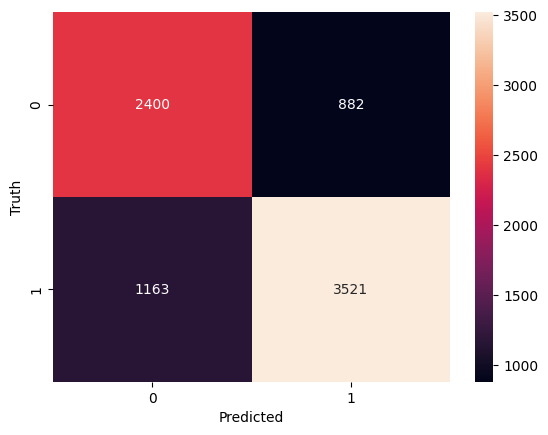

In [ ]:
#show confusion matrix of the test with a heatmap
cm = metrics.confusion_matrix(y_test, y_pred)
sn.heatmap(cm, annot=True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
features_list = list(X_train.columns)
feature_imp = pd.Series(model.feature_importances_, index=features_list).sort_values(ascending=False)
print(feature_imp)

FG_PCT_home     0.323809
FG3_PCT_home    0.209726
REB_home        0.177848
FT_PCT_home     0.172258
SEASON          0.116359
TEAM_ID_home    0.000000
TEAM_ID_away    0.000000
dtype: float64


#***Logistic Regression***

In [ ]:
#Load the dataset
df_lr = pd.read_csv('games.csv')
df_lr = df_lr.dropna()



In [ ]:
#Select features (same as Random Forest model)
features = ['FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'REB_home']
target = 'HOME_TEAM_WINS'

X = df_lr[features]
y = df_lr[target]

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts())

Dataset shape: (26552, 4)
Class distribution:
HOME_TEAM_WINS
1    15645
0    10907
Name: count, dtype: int64


In [ ]:
#Train/Test Split (70/30 same as Random Forest)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 18586 Test size: 7966


In [ ]:
#Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**F1 Score**


In [ ]:
#Predict & Evaluate
y_pred = lr_model.predict(X_test_scaled)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=['Away Wins','Home Wins']))


Accuracy: 0.7699
              precision    recall  f1-score   support

   Away Wins       0.74      0.69      0.71      3282
   Home Wins       0.79      0.83      0.81      4684

    accuracy                           0.77      7966
   macro avg       0.76      0.76      0.76      7966
weighted avg       0.77      0.77      0.77      7966



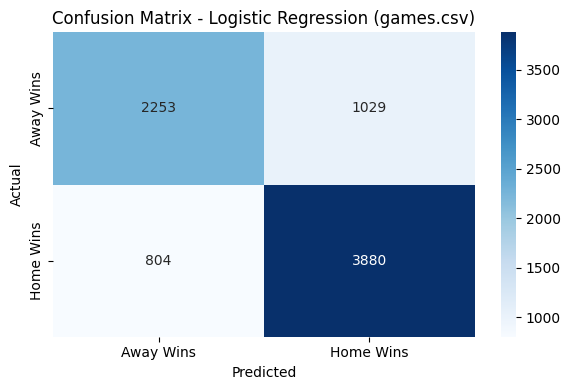

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Wins','Home Wins'],
            yticklabels=['Away Wins','Home Wins'])
plt.title('Confusion Matrix - Logistic Regression (games.csv)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
#Feature Coefficients
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': lr_model.coef_[0]})
coeff_df = coeff_df.sort_values('Coefficient', ascending=False)
print("Feature Coefficients (higher = stronger predictor of Home Win):")
print(coeff_df.to_string(index=False))

Feature Coefficients (higher = stronger predictor of Home Win):
     Feature  Coefficient
 FG_PCT_home     1.343167
    REB_home     1.035393
FG3_PCT_home     0.404154
 FT_PCT_home     0.305849


In [ ]:
#drop season column
df_lr = df_lr.drop('SEASON', axis=1)

In [ ]:
print('Random_forest Accuracy = .7474')
print(f"Logistic_regression Accuracy = {round(accuracy_score(y_test, y_pred), 4)}")

Random_forest Accuracy = .7474
Logistic_regression Accuracy = 0.7699


In [ ]:
import statsmodels.api as sm

# Add constant (intercept) to the feature matrix
X_sm = sm.add_constant(X)

# Fit the Logit model using statsmodels
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit()

# Display the summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.480613
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         HOME_TEAM_WINS   No. Observations:                26552
Model:                          Logit   Df Residuals:                    26547
Method:                           MLE   Df Model:                            4
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.2902
Time:                        12:13:36   Log-Likelihood:                -12761.
converged:                       True   LL-Null:                       -17979.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -21.1012      0.296    -71.394      0.000     -21.681     -20.522
FG_PCT_home     23.9650

In [ ]:
# Y= -21.1012 + 23.965(FG%) + 3.0466(FT%) + 3.6769(3PT%) + 0.1611(REB) + E

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# 5-Fold Cross-Validation for Logistic Regression
# Pipeline ensures scaling is applied correctly within each fold
lr_cv_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

cv_scores = cross_val_score(lr_cv_pipeline, X, y, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Results - Logistic Regression")
print("======================================================")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean Accuracy:  {cv_scores.mean():.4f}")
print(f"  Std Deviation:  {cv_scores.std():.4f}")
print(f"  95% CI:         ({cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f})")

5-Fold Cross-Validation Results - Logistic Regression
  Fold 1: 0.7550
  Fold 2: 0.7707
  Fold 3: 0.7637
  Fold 4: 0.7446
  Fold 5: 0.7791

  Mean Accuracy:  0.7626
  Std Deviation:  0.0120
  95% CI:         (0.7386, 0.7866)


#5 Fold Results

1.   0.7550
2.   0.7707
3.   0.7637
4.   0.7446
5.   0.7791


*   Mean 0.7626
*   Std Dev 0.012095%



#***RESULTS***
*   F1 Score = .77
*   Random forest = .75
*   Logistical regression = .77
*   Cross Validation results = .76



#***Recomendations***
1. FG% most impactful |
      1% increase in FG% -> 27% increase in winning odds
2. Rebounds next | Each rebound -> 17% increase in winning odds

In [ ]:
|